# 🔬 Segmentation des Lésions Cutanées — ISIC 2018
## PFE — Licence Professionnelle Big Data

**Objectif :** Segmenter automatiquement les lésions cutanées à partir d'images dermoscopiques  
**Dataset :** ISIC 2018 Task 1 — Lesion Boundary Segmentation  
**Modèle :** U-Net (PyTorch)  
**Méthodologie :** CRISP-DM

---
### Plan du notebook
1. 📦 Imports et configuration
2. 🔍 Phase 2 CRISP-DM — Exploration des données (EDA)
3. ⚙️ Phase 3 — Prétraitement et DataLoaders
4. 🧠 Phase 4 — Construction du modèle U-Net
5. 🚀 Phase 4 — Entraînement
6. 📊 Phase 5 — Évaluation et résultats
7. 🖼️ Visualisation des prédictions

---
## 1. 📦 Imports et configuration

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm.notebook import tqdm

# Ajoute le dossier racine du projet au path Python
# (pour pouvoir importer src/dataset.py, src/model.py, etc.)
ROOT = os.path.dirname(os.getcwd())  # remonte d'un niveau : notebooks/ -> ISIC_Project/
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.dataset import get_dataloaders, get_train_transforms, get_val_transforms
from src.model   import UNet
from src.utils   import DiceBCELoss, dice_score, iou_score, \
                        visualize_predictions, plot_training_curves

# ── Chemins vers le dataset ISIC ──
IMAGES_DIR = os.path.join(ROOT, 'data', 'Images')
MASKS_DIR  = os.path.join(ROOT, 'data', 'Masques')

# ── Hyperparamètres optimisés CPU ──
IMG_SIZE   = 128   # 128x128 pour CPU
BATCH_SIZE = 4     # petit batch pour CPU
NUM_EPOCHS = 20    # 20 epochs suffisent
LR         = 1e-4
NUM_WORKERS = 0    # obligatoire sur Windows

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 50)
print('  Configuration du projet')
print('=' * 50)
print(f'  Device      : {device}')
print(f'  PyTorch     : {torch.__version__}')
print(f'  Images dir  : {IMAGES_DIR}')
print(f'  Masks dir   : {MASKS_DIR}')
print(f'  Image size  : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Epochs      : {NUM_EPOCHS}')
print('=' * 50)

# Vérification rapide des dossiers
for path, label in [(IMAGES_DIR, 'Images'), (MASKS_DIR, 'Masques')]:
    if os.path.isdir(path):
        n = len(os.listdir(path))
        print(f'  ✔ {label} : {n} fichiers trouvés')
    else:
        print(f'  ✘ ERREUR : dossier introuvable → {path}')

  Configuration du projet
  Device      : cpu
  PyTorch     : 2.10.0+cpu
  Images dir  : c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\data\Images
  Masks dir   : c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\data\Masques
  Image size  : 128x128
  Batch size  : 4
  Epochs      : 20
  ✔ Images : 2596 fichiers trouvés
  ✔ Masques : 2596 fichiers trouvés


---
## 2. 🔍 Phase 2 CRISP-DM — Exploration des données (EDA)

On explore le dataset avant de le traiter. On vérifie :
- Le nombre d'images et masques
- Les dimensions des images
- Des exemples visuels de paires image/masque
- La distribution du ratio lésion/fond

In [2]:
# ── Comptage des fichiers ──
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')])
mask_files  = sorted([f for f in os.listdir(MASKS_DIR)  if f.endswith('.png')])

print(f'Nombre d\'images  : {len(image_files)}')
print(f'Nombre de masques : {len(mask_files)}')
print(f'\nExemple image  : {image_files[0]}')
print(f'Exemple masque : {mask_files[0]}')

Nombre d'images  : 2594
Nombre de masques : 2594

Exemple image  : ISIC_0000000.jpg
Exemple masque : ISIC_0000000_segmentation.png


In [3]:
# ── Analyse des dimensions des images ──
heights, widths = [], []
print('Analyse des dimensions (100 images)...')
for fname in image_files[:100]:
    img = cv2.imread(os.path.join(IMAGES_DIR, fname))
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f'Hauteur — min: {min(heights)}, max: {max(heights)}, moyenne: {np.mean(heights):.0f}')
print(f'Largeur  — min: {min(widths)},  max: {max(widths)},  moyenne: {np.mean(widths):.0f}')
print(f'\n→ Les images ont des tailles variables, on les redimensionne à {IMG_SIZE}x{IMG_SIZE}')

Analyse des dimensions (100 images)...
Hauteur — min: 722, max: 1944, moyenne: 1166
Largeur  — min: 962,  max: 2592,  moyenne: 1554

→ Les images ont des tailles variables, on les redimensionne à 128x128


✔ Figure sauvegardée → outputs/eda_samples.png


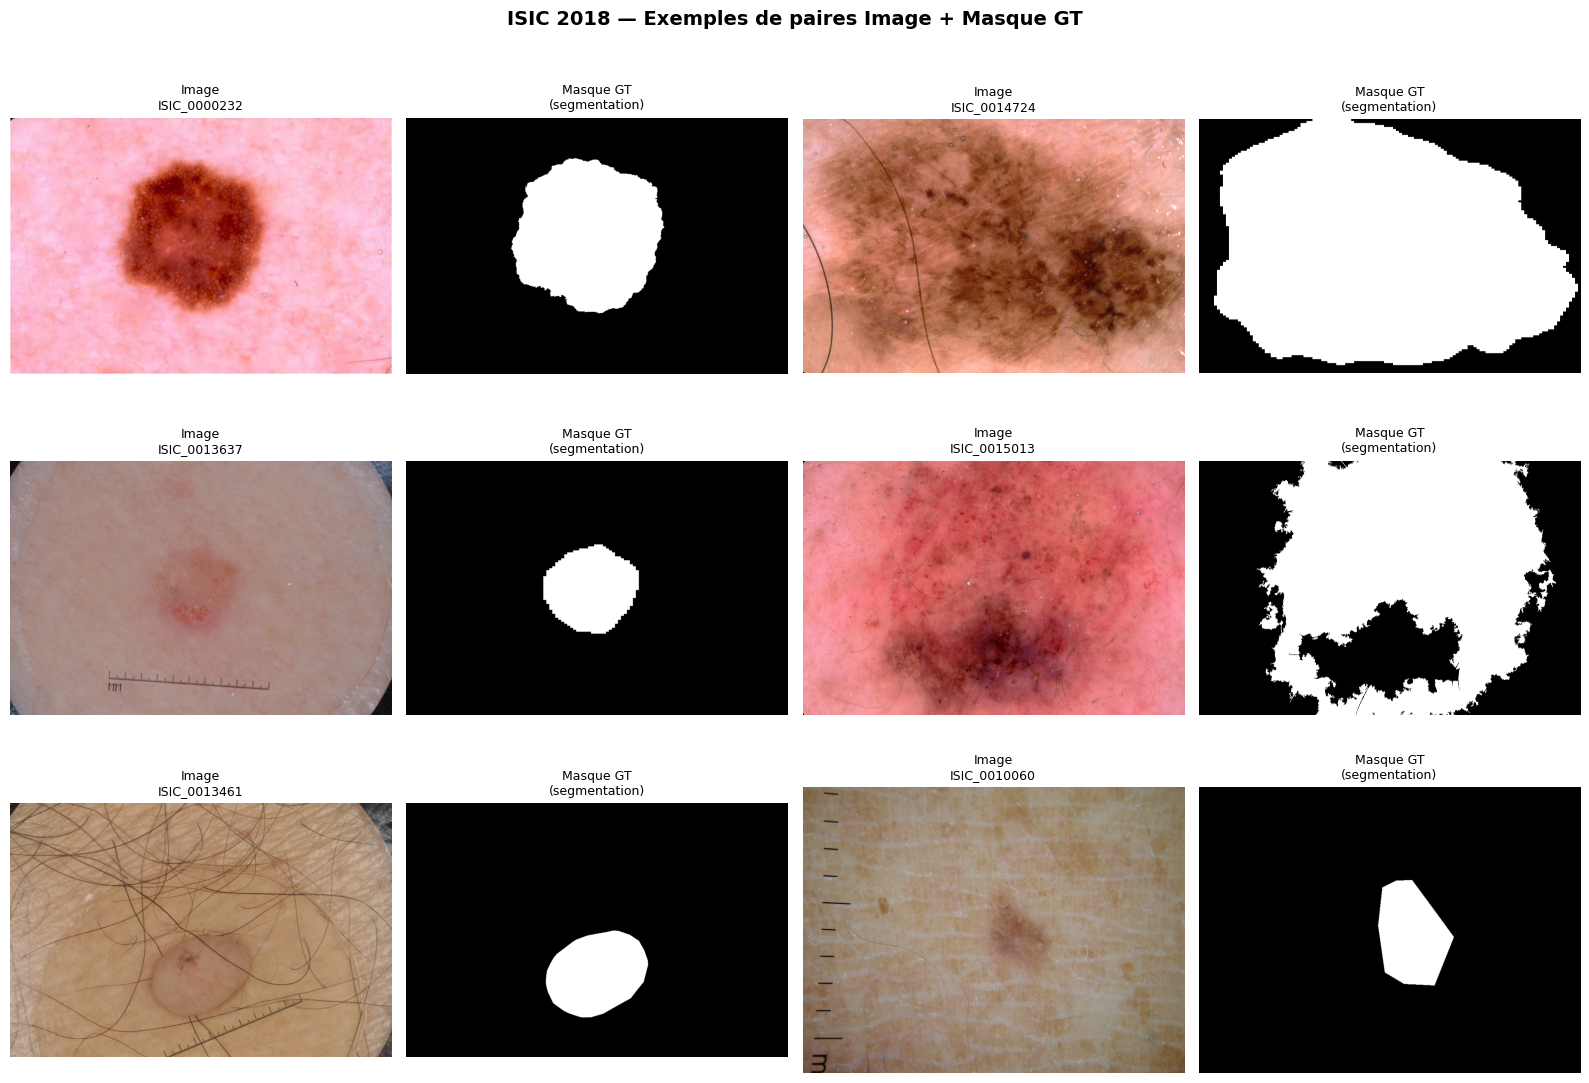

In [4]:
# ── Visualisation de 6 paires image / masque ──
np.random.seed(42)
indices = np.random.choice(len(image_files), 6, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('ISIC 2018 — Exemples de paires Image + Masque GT', fontsize=14, fontweight='bold', y=1.01)

for i, idx in enumerate(indices):
    img_name  = image_files[idx]
    img_id    = img_name.replace('.jpg', '')
    mask_name = f'{img_id}_segmentation.png'

    img  = cv2.imread(os.path.join(IMAGES_DIR, img_name))
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(MASKS_DIR, mask_name), cv2.IMREAD_GRAYSCALE)

    row = i // 2
    col = (i % 2) * 2

    axes[row, col].imshow(img)
    axes[row, col].set_title(f'Image\n{img_id[:18]}', fontsize=9)
    axes[row, col].axis('off')

    axes[row, col+1].imshow(mask, cmap='gray')
    axes[row, col+1].set_title('Masque GT\n(segmentation)', fontsize=9)
    axes[row, col+1].axis('off')

plt.tight_layout()
os.makedirs(os.path.join(ROOT, 'outputs'), exist_ok=True)
plt.savefig(os.path.join(ROOT, 'outputs', 'eda_samples.png'), dpi=150, bbox_inches='tight')
print('✔ Figure sauvegardée → outputs/eda_samples.png')
plt.show()

Calcul des ratios lésion/fond (200 masques)...

  Ratio moyen lésion : 31.0%
  Ratio min          : 1.5%
  Ratio max          : 93.2%
✔ Figure sauvegardée → outputs/eda_ratios.png


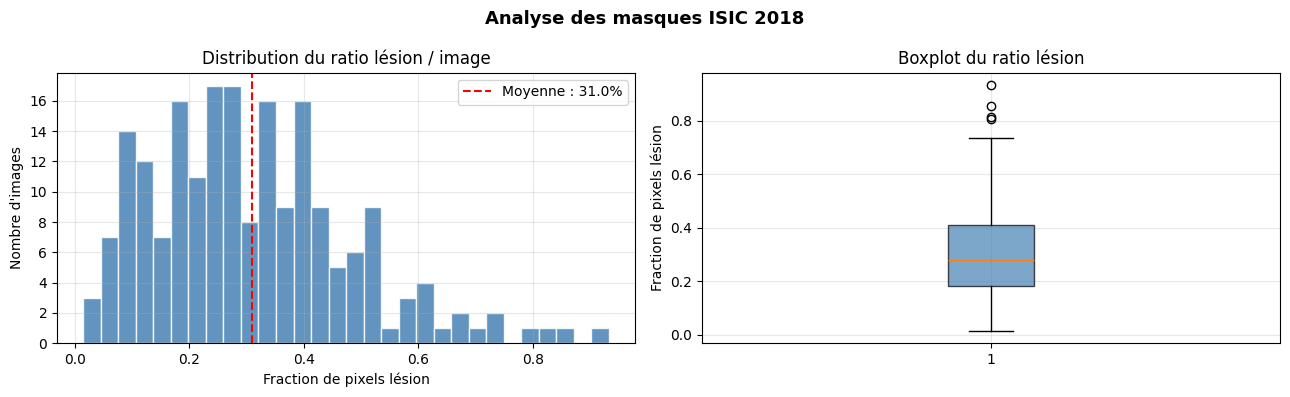

In [5]:
# ── Distribution du ratio lésion / image ──
ratios = []
print('Calcul des ratios lésion/fond (200 masques)...')
for fname in mask_files[:200]:
    mask  = cv2.imread(os.path.join(MASKS_DIR, fname), cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        ratio = (mask > 127).sum() / mask.size
        ratios.append(ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Analyse des masques ISIC 2018', fontsize=13, fontweight='bold')

ax1.hist(ratios, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(np.mean(ratios), color='red', linestyle='--', linewidth=1.5,
            label=f'Moyenne : {np.mean(ratios)*100:.1f}%')
ax1.set_title('Distribution du ratio lésion / image')
ax1.set_xlabel('Fraction de pixels lésion')
ax1.set_ylabel('Nombre d\'images')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplot
ax2.boxplot(ratios, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
ax2.set_title('Boxplot du ratio lésion')
ax2.set_ylabel('Fraction de pixels lésion')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'outputs', 'eda_ratios.png'), dpi=150, bbox_inches='tight')
print(f'\n  Ratio moyen lésion : {np.mean(ratios)*100:.1f}%')
print(f'  Ratio min          : {np.min(ratios)*100:.1f}%')
print(f'  Ratio max          : {np.max(ratios)*100:.1f}%')
print('✔ Figure sauvegardée → outputs/eda_ratios.png')
plt.show()

---
## 3. ⚙️ Phase 3 — Prétraitement et DataLoaders

On prépare les données pour l'entraînement :
- **Resize** : toutes les images → 128×128
- **Normalisation** : pixels divisés par 255, standardisation ImageNet
- **Augmentation** (train only) : flip, rotation, bruit, etc.
- **Split** : 80% train / 10% val / 10% test

In [6]:
# ── Création des DataLoaders ──
train_loader, val_loader, test_loader = get_dataloaders(
    images_dir  = IMAGES_DIR,
    masks_dir   = MASKS_DIR,
    img_size    = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    seed        = 42,
)

print(f'\nNombre de batches → Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

# Vérification des dimensions
images_b, masks_b = next(iter(train_loader))
print(f'\nDimensions d\'un batch :')
print(f'  Images : {images_b.shape}  → [Batch, Canaux, H, W]')
print(f'  Masques: {masks_b.shape}  → [Batch, 1, H, W]')
print(f'  Dtype  : {images_b.dtype}')
print(f'  Masque valeurs : min={masks_b.min():.1f}, max={masks_b.max():.1f}')

[Split] Train: 2075 | Val: 259 | Test: 260
[Dataset] 2594 images chargées depuis c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\data\Images
[Dataset] 2594 images chargées depuis c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\data\Images
[Dataset] 2594 images chargées depuis c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\data\Images

Nombre de batches → Train: 519 | Val: 65 | Test: 65


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Dimensions d'un batch :
  Images : torch.Size([4, 3, 128, 128])  → [Batch, Canaux, H, W]
  Masques: torch.Size([4, 1, 128, 128])  → [Batch, 1, H, W]
  Dtype  : torch.float32
  Masque valeurs : min=0.0, max=1.0


✔ Figure sauvegardée → outputs/preprocessing_examples.png


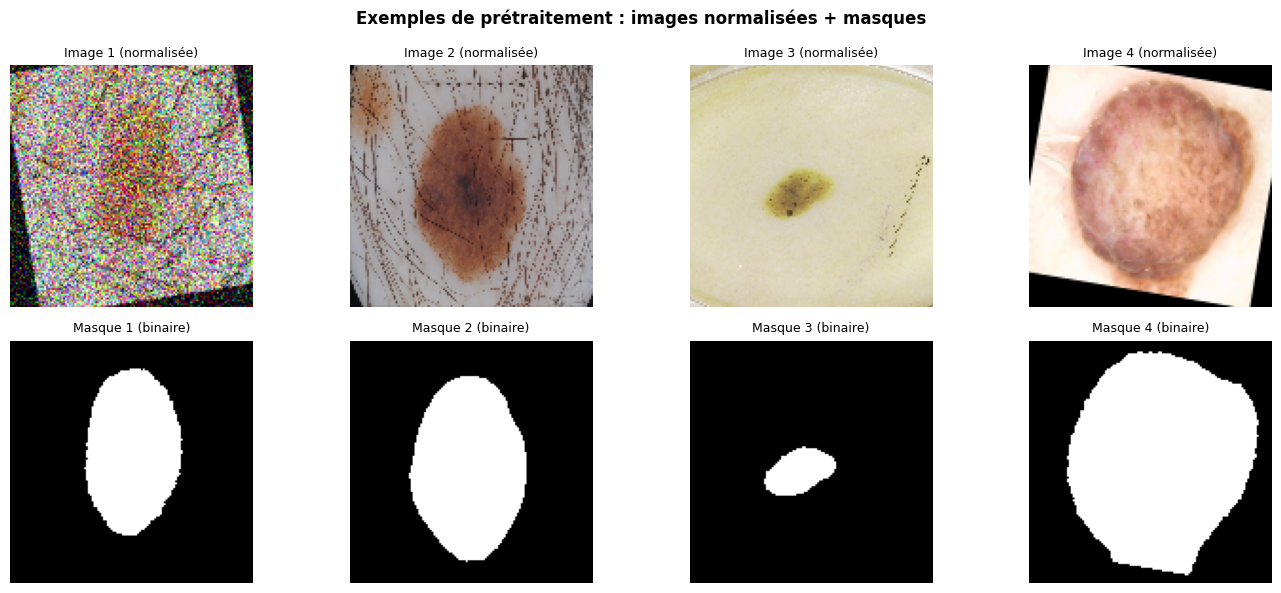

In [7]:
# ── Visualisation de l'augmentation ──
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Exemples de prétraitement : images normalisées + masques', fontsize=12, fontweight='bold')

for i in range(4):
    img_show  = (images_b[i].cpu() * std + mean).permute(1,2,0).numpy().clip(0,1)
    mask_show = masks_b[i, 0].cpu().numpy()

    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f'Image {i+1} (normalisée)', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_show, cmap='gray')
    axes[1, i].set_title(f'Masque {i+1} (binaire)', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'outputs', 'preprocessing_examples.png'), dpi=150, bbox_inches='tight')
print('✔ Figure sauvegardée → outputs/preprocessing_examples.png')
plt.show()

---
## 4. 🧠 Phase 4 — Modèle U-Net

Architecture U-Net :
- **Encodeur** : 4 blocs Conv+MaxPool → extrait les features
- **Bottleneck** : couche la plus profonde
- **Décodeur** : 4 blocs UpConv → reconstruit le masque
- **Skip connections** : relient encodeur ↔ décodeur pour préserver les détails

In [8]:
# ── Instanciation du U-Net ──
model = UNet(in_channels=3, out_channels=1).to(device)

# Test rapide avec un faux batch
x_test = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    y_test = model(x_test)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Architecture U-Net')
print('=' * 40)
print(f'  Entrée  : {x_test.shape}')
print(f'  Sortie  : {y_test.shape}')
print(f'  Paramètres entraînables : {params:,}')
print(f'  Device  : {device}')
print('=' * 40)
print('✔ Modèle prêt !')

Architecture U-Net
  Entrée  : torch.Size([1, 3, 128, 128])
  Sortie  : torch.Size([1, 1, 128, 128])
  Paramètres entraînables : 31,037,633
  Device  : cpu
✔ Modèle prêt !


---
## 5. 🚀 Phase 4 — Entraînement

**⏱ Durée estimée sur CPU : ~1h30 pour 20 epochs**

- **Optimizer** : Adam (lr=1e-4)
- **Loss** : Dice + BCE (combinée)
- **Scheduler** : ReduceLROnPlateau (réduit le lr si pas d'amélioration)
- Le meilleur modèle est sauvegardé automatiquement

In [9]:
# ── Préparation de l'entraînement ──
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
criterion = DiceBCELoss()

# Historique
train_losses, val_losses = [], []
train_dices,  val_dices  = [], []
best_val_dice = 0.0

CKPT_DIR = os.path.join(ROOT, 'outputs', 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print('✔ Optimizer, scheduler et loss prêts')
print(f'✔ Checkpoints → {CKPT_DIR}')

✔ Optimizer, scheduler et loss prêts
✔ Checkpoints → c:\Users\hp\Desktop\BUT\IA\project\ISIC_Project\outputs\checkpoints


In [ ]:
# ── Boucle d'entraînement ──
print(f'Début de l\'entraînement — {NUM_EPOCHS} epochs sur {device}')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── TRAIN ──
    model.train()
    t_loss, t_dice = 0.0, 0.0

    loop_train = tqdm(train_loader,
                      desc=f'Epoch {epoch:02d}/{NUM_EPOCHS} [Train]',
                      leave=False)
    for images, masks in loop_train:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_dice += dice_score(preds.detach(), masks)
        loop_train.set_postfix(loss=f'{loss.item():.4f}')

    # ── VALIDATION ──
    model.eval()
    v_loss, v_dice, v_iou = 0.0, 0.0, 0.0

    with torch.no_grad():
        loop_val = tqdm(val_loader,
                        desc=f'Epoch {epoch:02d}/{NUM_EPOCHS} [Val]  ',
                        leave=False)
        for images, masks in loop_val:
            images, masks = images.to(device), masks.to(device)
            preds  = model(images)
            v_loss += criterion(preds, masks).item()
            v_dice += dice_score(preds, masks)
            v_iou  += iou_score(preds, masks)

    # ── Moyennes ──
    t_loss /= len(train_loader); t_dice /= len(train_loader)
    v_loss /= len(val_loader);   v_dice /= len(val_loader)
    v_iou  /= len(val_loader)

    scheduler.step(v_dice)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_dices.append(t_dice);  val_dices.append(v_dice)

    status = ''
    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save({
            'epoch'             : epoch,
            'model_state_dict'  : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice'          : v_dice,
            'val_iou'           : v_iou,
        }, os.path.join(CKPT_DIR, 'best_model.pth'))
        status = '  ✔ Meilleur modèle sauvegardé'

    print(f'[{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {t_loss:.4f}  Dice: {t_dice:.4f}  |  '
          f'Val Loss: {v_loss:.4f}  Dice: {v_dice:.4f}  IoU: {v_iou:.4f}'
          + status)

print('\n' + '=' * 65)
print(f'  Entraînement terminé !')
print(f'  Meilleur Dice Validation : {best_val_dice:.4f}')
print('=' * 65)

Début de l'entraînement — 20 epochs sur cpu


Epoch 01/20 [Train]:   0%|          | 0/519 [00:00<?, ?it/s]

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


---
## 6. 📊 Phase 5 — Évaluation et courbes

In [ ]:
# ── Courbes d'entraînement ──
plot_training_curves(
    train_losses, val_losses,
    train_dices,  val_dices,
    save_path=os.path.join(ROOT, 'outputs', 'training_curves.png')
)

In [ ]:
# ── Chargement du meilleur modèle ──
ckpt_path  = os.path.join(CKPT_DIR, 'best_model.pth')
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Modèle chargé — Epoch {checkpoint["epoch"]} | Val Dice: {checkpoint["val_dice"]:.4f}')

# ── Évaluation sur le test set ──
test_dice, test_iou = 0.0, 0.0
first_batch = None

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Évaluation test set'):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        test_dice += dice_score(preds, masks)
        test_iou  += iou_score(preds, masks)
        if first_batch is None:
            first_batch = (images.cpu(), masks.cpu(), preds.cpu())

test_dice /= len(test_loader)
test_iou  /= len(test_loader)

print('\n' + '=' * 45)
print('  RÉSULTATS FINAUX — Test Set')
print('=' * 45)
print(f'  Dice Score : {test_dice:.4f}')
print(f'  IoU  Score : {test_iou:.4f}')
print('=' * 45)
print('\n→ Ces chiffres vont dans ton rapport PFE !')

---
## 7. 🖼️ Visualisation des prédictions

In [ ]:
# ── Visualisation image / masque GT / prédiction ──
images_v, masks_v, preds_v = first_batch

os.makedirs(os.path.join(ROOT, 'outputs', 'predictions'), exist_ok=True)

visualize_predictions(
    images_v, masks_v, preds_v,
    n=4,
    save_path=os.path.join(ROOT, 'outputs', 'predictions', 'test_predictions.png')
)

In [ ]:
# ── Overlay : lésion prédite sur l'image originale ──
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Résultats — Image originale avec overlay de la prédiction', fontsize=13, fontweight='bold')

for i in range(min(4, images_v.shape[0])):
    # Image dénormalisée
    img_np   = (images_v[i] * std_t + mean_t).permute(1,2,0).numpy().clip(0,1)
    pred_np  = (torch.sigmoid(preds_v[i,0]) > 0.5).numpy().astype(np.uint8)
    gt_np    = masks_v[i,0].numpy()

    # Overlay rouge = prédiction
    overlay  = img_np.copy()
    overlay[pred_np == 1] = overlay[pred_np == 1] * 0.5 + np.array([1,0,0]) * 0.5

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f'Image originale {i+1}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Prédiction (rouge)', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'outputs', 'predictions', 'overlay_predictions.png'),
            dpi=150, bbox_inches='tight')
print('✔ Overlay sauvegardé → outputs/predictions/overlay_predictions.png')
plt.show()

---
## Résumé CRISP-DM

| Phase | Description | Résultat |
|-------|-------------|----------|
| 1. Compréhension du domaine | Segmentation lésions cutanées — détection mélanome | ✅ |
| 2. Compréhension des données | EDA : ISIC 2018, 2594 images dermoscopiques | ✅ |
| 3. Prétraitement | Resize 128×128, normalisation ImageNet, augmentation Albumentations | ✅ |
| 4. Modélisation | U-Net PyTorch, 31M paramètres, loss Dice+BCE | ✅ |
| 5. Évaluation | Dice Score + IoU sur test set | ✅ |
| 6. Déploiement | Rapport PFE + présentation soutenance | 📝 |

---
### Fichiers générés dans `outputs/`
- `eda_samples.png` — exemples image/masque
- `eda_ratios.png` — distribution des lésions
- `preprocessing_examples.png` — images après prétraitement
- `training_curves.png` — courbes Loss + Dice
- `predictions/test_predictions.png` — prédictions finales
- `predictions/overlay_predictions.png` — overlay sur image originale
- `checkpoints/best_model.pth` — meilleur modèle entraîné